# EDA: Animals-10 Dataset

## 1. Setup

In [2]:
import os
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import kagglehub
import seaborn as sns

path = kagglehub.dataset_download("alessiocorrado99/animals10")
data_dir = os.path.join(path, "raw-img")

print(f"Dataset downloaded to: {path}")
print(f"Images directory: {data_dir}")

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Dataset downloaded to: /Users/zaharguzij/.cache/kagglehub/datasets/alessiocorrado99/animals10/versions/2
Images directory: /Users/zaharguzij/.cache/kagglehub/datasets/alessiocorrado99/animals10/versions/2/raw-img


The original dataset uses Italian folder names. We map them to English.

In [4]:
LABEL_MAP = {
    "gallina":    "chicken",
    "ragno":      "spider",
    "gatto":      "cat",
    "farfalla":   "butterfly",
    "mucca":      "cow",
    "cavallo":    "horse",
    "cane":       "dog",
    "pecora":     "sheep",
    "scoiattolo": "squirrel",
    "elefante":   "elephant",
}

print(f"Mapped {len(LABEL_MAP)} classes.")
print(f"Target animals: {', '.join(LABEL_MAP.values())}")

Mapped 10 classes.
Target animals: chicken, spider, cat, butterfly, cow, horse, dog, sheep, squirrel, elephant


## 2. Class Distribution

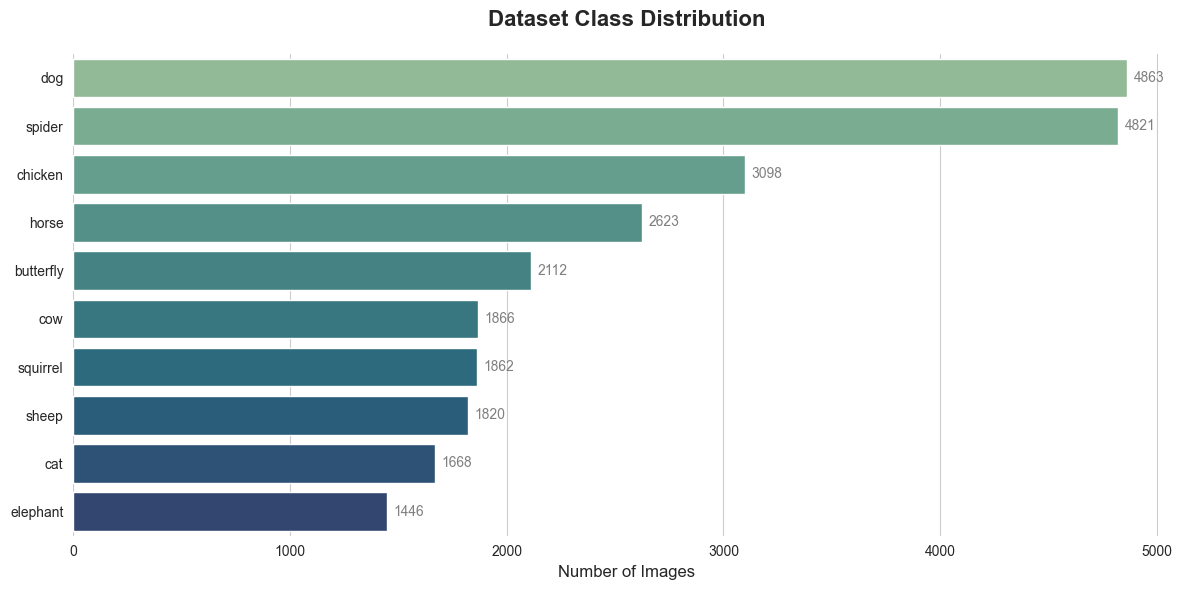

In [11]:
class_counts = {
    LABEL_MAP[cls]: len(os.listdir(os.path.join(data_dir, cls)))
    for cls in os.listdir(data_dir)
}

df = pd.DataFrame(list(class_counts.items()), columns=['Class', 'Count'])
df = df.sort_values('Count', ascending=False)

plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")

ax = sns.barplot(
    data=df, 
    x='Count', 
    y='Class', 
    palette='crest',
    hue='Class', 
    legend=False
)

for i in ax.containers:
    ax.bar_label(i, padding=5, fontsize=10, color='gray')

plt.title('Dataset Class Distribution', fontsize=16, pad=20, fontweight='bold')
plt.xlabel('Number of Images', fontsize=12)
plt.ylabel(None) 
sns.despine(left=True, bottom=True) 
plt.tight_layout()
plt.show()

In [12]:
max_count = max(class_counts.values())
min_count = min(class_counts.values())
print(f"Imbalance ratio: {max_count / min_count:.1f}x")

Imbalance ratio: 3.4x


The dataset exhibits a moderate imbalance with a ratio of *3.4x* between the majority class (*spider*) and the minority class (*elephant*).

So, simple accuracy score might be misleading; F1 Score will be used for evaluation.
To prevent bias towards majority classes, *Class Weights* will be applied during the training phase.

## 3. Visual Data Inspection

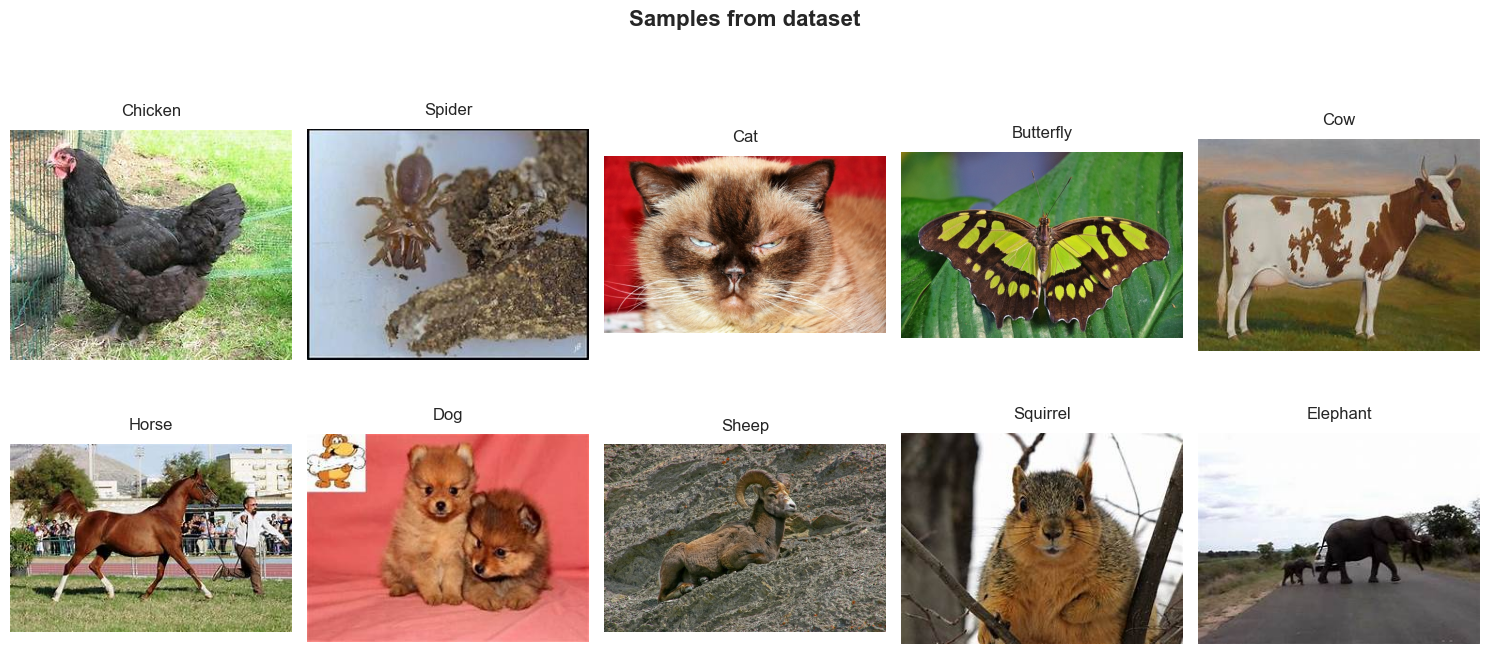

In [14]:
fig, axes = plt.subplots(2, 5, figsize=(15, 7))
fig.suptitle('Samples from dataset', fontsize=16, fontweight='bold', y=1.02)

for ax, (folder, label) in zip(axes.flat, LABEL_MAP.items()):
    folder_path = os.path.join(data_dir, folder)
    
    images = [f for f in os.listdir(folder_path) if f.lower()]
    
    random_img = random.choice(images)
    img_path = os.path.join(folder_path, random_img)
    
    with Image.open(img_path) as img:
        ax.imshow(img)
        ax.set_title(label.capitalize(), fontsize=12, pad=10)
        ax.axis("off")

plt.tight_layout()
plt.show()

The images appear to be different sizes

In [18]:
widths, heights = [], []

for folder in os.listdir(data_dir):
    folder_path = os.path.join(data_dir, folder)
    for img_file in os.listdir(folder_path):
        try:
            img = Image.open(os.path.join(folder_path, img_file))
            w, h = img.size
            widths.append(w)
            heights.append(h)
        except Exception:
            continue

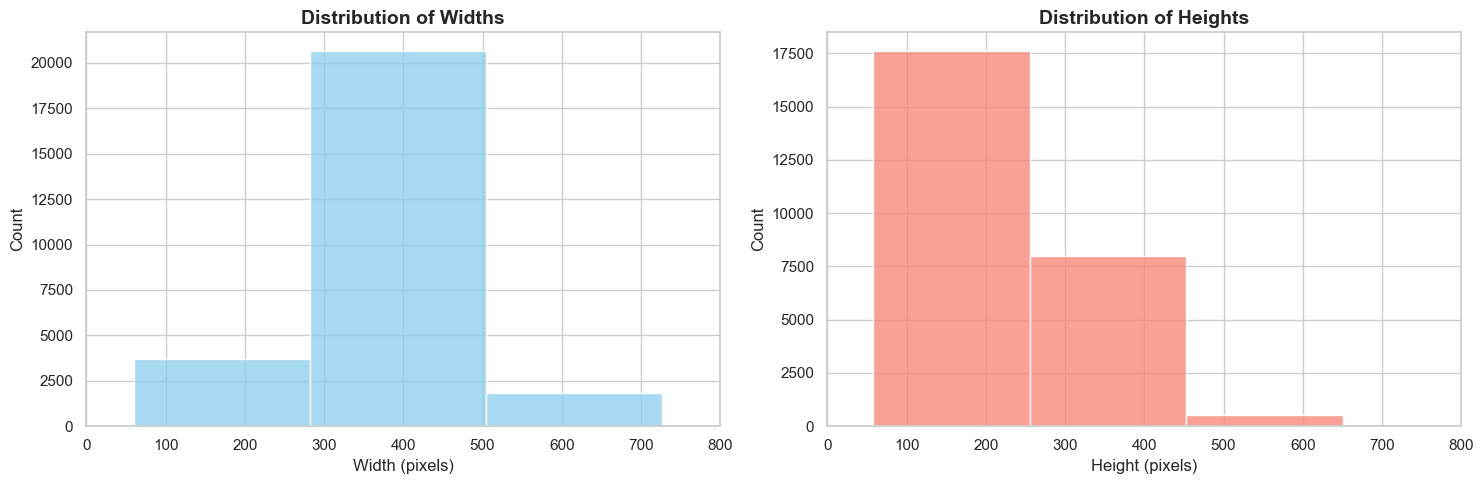

In [25]:
sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(widths, bins=30, ax=axes[0], color='skyblue')
axes[0].set_title('Distribution of Widths', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Width (pixels)')
axes[0].set_ylabel('Count')
axes[0].set_xlim(0, 800)

sns.histplot(heights, bins=30, ax=axes[1], color='salmon')
axes[1].set_title('Distribution of Heights', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Height (pixels)')
axes[1].set_ylabel('Count')
axes[1].set_xlim(0, 800)

plt.tight_layout()
plt.show()

In [27]:
df_dims = pd.DataFrame({
    'Width': widths,
    'Height': heights
})

In [28]:
df_dims.describe()

,Width,Height
count,26179.000000,26179.000000
mean,320.038810,252.630162
std,196.935326,148.403298
min,60.000000,57.000000
25%,300.000000,200.000000
50%,300.000000,225.000000
75%,300.000000,300.000000
max,6720.000000,6000.000000


Since raw images have different resolutions and aspect ratios, we need that: 

All images will be scaled to a standard *224x224* resolution.
To avoid distortion of animal features, we will use *Center Cropping* during inference and *Random Resized Cropping* during training.
Last but not least pixel values will be scaled using ImageNet mean and standard deviation to speed up convergence.